In [1]:
# Ejecuta esto en una celda Colab/Kaggle
!apt-get install ffmpeg libgl1 -y
!pip install -q imageio matplotlib numpy open3d
!git clone https://github.com/graphdeco-inria/gaussian-splatting.git
%cd gaussian-splatting
!pip install -q numpy imageio matplotlib open3d plyfile scipy



Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgl1 is already the newest version (1.4.0-1).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 196 not upgraded.
fatal: destination path 'gaussian-splatting' already exists and is not an empty directory.
/kaggle/working/gaussian-splatting


In [2]:
# Arreglar el clon existente
#%cd /content/gaussian-splatting
!git submodule update --init --recursive
!apt-get update
!apt-get install -y ffmpeg libgl1
!pip install imageio matplotlib numpy open3d plyfile scipy
%cd /content/gaussian-splatting
!ls ./submodules/
!pip install ./submodules/simple-knn
!pip install ./submodules/diff-gaussian-rasterization
!pip install ./submodules/fused-ssim



Hit:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease                          
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease                                              
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease                                    
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease                                      
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease    
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,747 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jamm

In [3]:
# 🛠️ Instalar dependencias y clonar

#%cd /kaggle/working/gaussian-splatting
#!git submodule update --init --recursive



# 📁 Preparar carpetas
#!mkdir -p data/ficus/train data/ficus/val data/ficus/test

In [4]:
import kagglehub

# Descargar la última versión del dataset
path = kagglehub.dataset_download("nguyenhung1903/nerf-synthetic-dataset")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/nerf-synthetic-dataset


In [5]:
import os
import kagglehub # Ya lo tienes importado en una celda anterior, pero es bueno tenerlo cerca si trabajas aquí.

# Define las rutas de origen y destino de manera más robusta
# 'path' viene de tu celda anterior `kagglehub.dataset_download`
dataset_root_path = path # Este es el path que te dio kagglehub.dataset_download
#ficus_source_path = os.path.join(dataset_root_path, "nerf_synthetic", "lego")
#/kaggle/input/nerf-synthetic-dataset/nerf_synthetic/ficus
ficus_source_path = os.path.join(dataset_root_path, "nerf_synthetic", "ficus")

gs_data_target_path = "/content/gaussian-splatting/data/ficus"
#/kaggle/input/nerf-synthetic-dataset/nerf_synthetic/lego
# 📁 Crear el directorio de destino si no existe
!mkdir -p {gs_data_target_path}

# 🔄 Copiar TODO el contenido de la carpeta 'ficus'
# Esto incluye las subcarpetas (train, test, val) y los archivos transforms_*.json
!cp -r {ficus_source_path}/* {gs_data_target_path}/

# Opcional: Verifica el contenido para asegurarte de que todo se copió correctamente
print(f"Contenido de {gs_data_target_path}:")
!ls -l {gs_data_target_path}

Contenido de /content/gaussian-splatting/data/ficus:
total 28512
-rw-r--r-- 1 root root 274530 Jun 23 12:42 r_0.png
-rw-r--r-- 1 root root 198780 Jun 23 12:42 r_10.png
-rw-r--r-- 1 root root 318568 Jun 23 12:42 r_11.png
-rw-r--r-- 1 root root 302519 Jun 23 12:42 r_12.png
-rw-r--r-- 1 root root 281150 Jun 23 12:42 r_13.png
-rw-r--r-- 1 root root 131371 Jun 23 12:42 r_14.png
-rw-r--r-- 1 root root 337128 Jun 23 12:42 r_15.png
-rw-r--r-- 1 root root 265592 Jun 23 12:42 r_16.png
-rw-r--r-- 1 root root 272661 Jun 23 12:42 r_17.png
-rw-r--r-- 1 root root 261038 Jun 23 12:42 r_18.png
-rw-r--r-- 1 root root 279580 Jun 23 12:42 r_19.png
-rw-r--r-- 1 root root 266077 Jun 23 12:42 r_1.png
-rw-r--r-- 1 root root 314448 Jun 23 12:42 r_20.png
-rw-r--r-- 1 root root 284512 Jun 23 12:42 r_21.png
-rw-r--r-- 1 root root 326804 Jun 23 12:42 r_22.png
-rw-r--r-- 1 root root 268962 Jun 23 12:42 r_23.png
-rw-r--r-- 1 root root 293672 Jun 23 12:42 r_24.png
-rw-r--r-- 1 root root 327283 Jun 23 12:42 r_25.png
-

In [6]:
import os

for root, dirs, files in os.walk(path):
    print(f"📂 {root}")
    for f in files[:5]:  # Mostrar los primeros 5 archivos por carpeta
        print("   └──", f)


📂 /kaggle/input/nerf-synthetic-dataset
📂 /kaggle/input/nerf-synthetic-dataset/nerf_synthetic
   └── README.txt
📂 /kaggle/input/nerf-synthetic-dataset/nerf_synthetic/ship
   └── transforms_test.json
   └── transforms_train.json
   └── transforms_val.json
📂 /kaggle/input/nerf-synthetic-dataset/nerf_synthetic/ship/val
   └── r_13.png
   └── r_50.png
   └── r_11.png
   └── r_20.png
   └── r_33.png
📂 /kaggle/input/nerf-synthetic-dataset/nerf_synthetic/ship/test
   └── r_104_depth_0002.png
   └── r_127.png
   └── r_13.png
   └── r_30_depth_0002.png
   └── r_163_depth_0002.png
📂 /kaggle/input/nerf-synthetic-dataset/nerf_synthetic/ship/train
   └── r_13.png
   └── r_50.png
   └── r_11.png
   └── r_20.png
   └── r_33.png
📂 /kaggle/input/nerf-synthetic-dataset/nerf_synthetic/mic
   └── transforms_test.json
   └── transforms_train.json
   └── transforms_val.json
📂 /kaggle/input/nerf-synthetic-dataset/nerf_synthetic/mic/val
   └── r_13.png
   └── r_50.png
   └── r_11.png
   └── r_20.png
   └── r_3

In [7]:
!mkdir -p /content/gaussian-splatting/data/ficus
!cp /kaggle/input/nerf-synthetic-dataset/nerf_synthetic/ficus/train/*.png /content/gaussian-splatting/data/ficus/

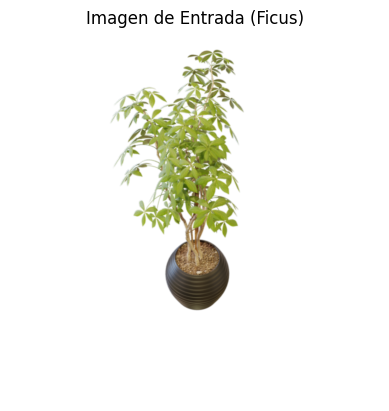

In [8]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os

input_img_path = '/kaggle/input/nerf-synthetic-dataset/nerf_synthetic/ficus/test/r_0.png'  # Una imagen que sí existe

if os.path.exists(input_img_path):
    img = imageio.imread(input_img_path)
    plt.imshow(img)
    plt.title("Imagen de Entrada (Ficus)")
    plt.axis('off')
    plt.show()
else:
    print("❌ No se encontró la imagen de entrada:", input_img_path)


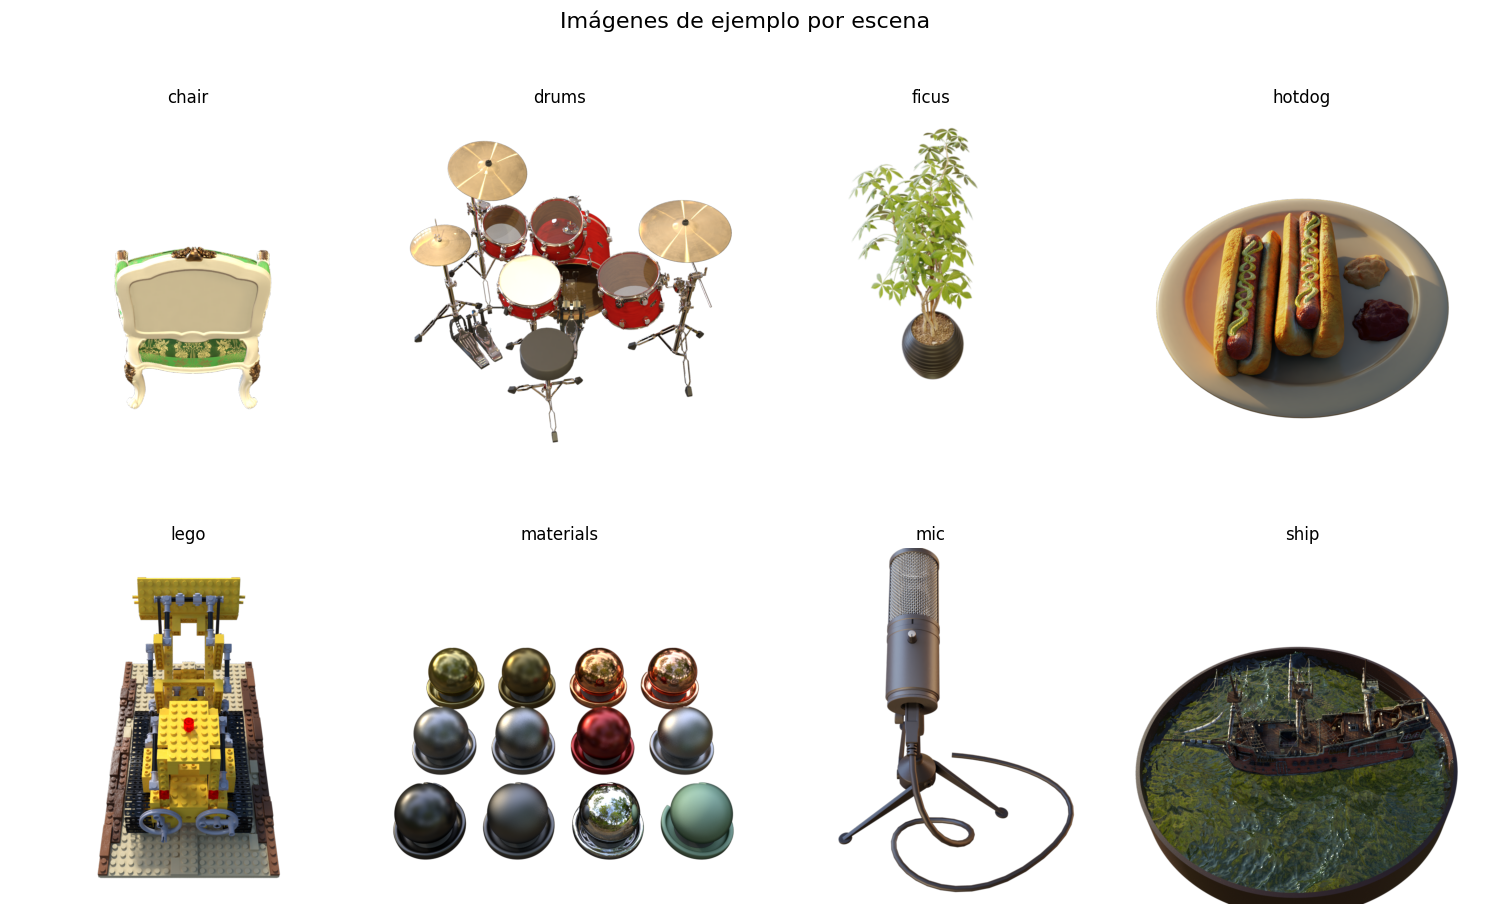

In [9]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os

# Ruta base del dataset
base_path = '/kaggle/input/nerf-synthetic-dataset/nerf_synthetic'

# Lista de carpetas (escenas)
scenes = ['chair', 'drums', 'ficus', 'hotdog', 'lego', 'materials', 'mic', 'ship']

# Tamaño del gráfico
plt.figure(figsize=(15, 10))

# Mostrar una imagen por carpeta
for idx, scene in enumerate(scenes):
    img_path = os.path.join(base_path, scene, 'test', 'r_0.png')
    
    if os.path.exists(img_path):
        img = imageio.imread(img_path)
        plt.subplot(2, 4, idx + 1)
        plt.imshow(img)
        plt.title(scene)
        plt.axis('off')
    else:
        print(f"❌ Imagen no encontrada: {img_path}")

plt.suptitle("Imágenes de ejemplo por escena", fontsize=16)
plt.tight_layout()
plt.show()


In [10]:
!cp /kaggle/input/nerf-synthetic-dataset/nerf_synthetic/ficus/*.json /content/gaussian-splatting/data/ficus/

In [11]:
!cat /content/gaussian-splatting/data/ficus/transforms_train.json | grep file_path


            "file_path": "./train/r_0",
            "file_path": "./train/r_1",
            "file_path": "./train/r_2",
            "file_path": "./train/r_3",
            "file_path": "./train/r_4",
            "file_path": "./train/r_5",
            "file_path": "./train/r_6",
            "file_path": "./train/r_7",
            "file_path": "./train/r_8",
            "file_path": "./train/r_9",
            "file_path": "./train/r_10",
            "file_path": "./train/r_11",
            "file_path": "./train/r_12",
            "file_path": "./train/r_13",
            "file_path": "./train/r_14",
            "file_path": "./train/r_15",
            "file_path": "./train/r_16",
            "file_path": "./train/r_17",
            "file_path": "./train/r_18",
            "file_path": "./train/r_19",
            "file_path": "./train/r_20",
            "file_path": "./train/r_21",
            "file_path": "./train/r_22",
            "file_path": "./train/r_23",
            "file_path": "

In [12]:
import json
import os

def fix_json_filepaths(json_path, split_name):
    with open(json_path, 'r') as f:
        data = json.load(f)

    changed = 0
    for i, frame in enumerate(data["frames"]):
        old_path = frame["file_path"]
        filename = os.path.basename(old_path)
        new_path = f"./{split_name}/{filename}"
        if old_path != new_path:
            data["frames"][i]["file_path"] = new_path
            changed += 1

    with open(json_path, 'w') as f:
        json.dump(data, f, indent=4)

    print(f"✅ {json_path} actualizado: {changed} rutas corregidas.")

base = "/kaggle/working/gaussian-splatting/data/ficus"
fix_json_filepaths(f"{base}/transforms_train.json", "train")
fix_json_filepaths(f"{base}/transforms_val.json", "val")
fix_json_filepaths(f"{base}/transforms_test.json", "test")


✅ /kaggle/working/gaussian-splatting/data/ficus/transforms_train.json actualizado: 0 rutas corregidas.
✅ /kaggle/working/gaussian-splatting/data/ficus/transforms_val.json actualizado: 0 rutas corregidas.
✅ /kaggle/working/gaussian-splatting/data/ficus/transforms_test.json actualizado: 0 rutas corregidas.


In [13]:
#!python train.py -s data/ficus -m output/ficus
!python train.py -s data/ficus -m output/ficus --iterations 150000 --sh_degree 3
#!python train.py -s data/ficus -m output/ficus --iterations 50000 --sh_degree 3

python3: can't open file '/content/gaussian-splatting/train.py': [Errno 2] No such file or directory


## PSNR: El PSNR es una medida que compara la calidad entre la imagen original y la imagen reconstruida o generada por tu modelo.

## L1: La métrica L1 se refiere al error absoluto promedio entre la imagen original y la imagen generada o reconstruida.

In [14]:
!python render.py -m output/ficus -s data/ficus


python3: can't open file '/content/gaussian-splatting/render.py': [Errno 2] No such file or directory


## 300/300: Número total de iteraciones o pasos del proceso de renderizado

In [15]:
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os

# ¡ESTA ES LA RUTA CORRECTA SEGÚN TU ÚLTIMA CAPTURA DE PANTALLA!
rendered_image_path = 'output/ficus/train/ours_150000/renders/00000.png'

# Opcional: Lista los archivos en la carpeta de renders para verificar los nombres
print(f"Archivos encontrados en {os.path.dirname(rendered_image_path)}:")
!ls -l {os.path.dirname(rendered_image_path)}

if os.path.exists(rendered_image_path):
    img = imageio.imread(rendered_image_path)
    plt.imshow(img)
    plt.title("¡Imagen Renderizada del Ficus (Desde Entrenamiento)!")
    plt.axis('off')
    plt.show()
else:
    print(f"❌ No se encontró la imagen renderizada en: {rendered_image_path}")
    print("Verifica si el nombre del archivo (ej. '00000.png') es correcto.")

Archivos encontrados en output/ficus/train/ours_150000/renders:
ls: cannot access 'output/ficus/train/ours_150000/renders': No such file or directory
❌ No se encontró la imagen renderizada en: output/ficus/train/ours_150000/renders/00000.png
Verifica si el nombre del archivo (ej. '00000.png') es correcto.


In [16]:
# Asegúrate de que las imágenes estén en la carpeta correcta y que los nombres sean secuenciales (ej. 00000.png, 00001.png, ...)
renders_dir = "output/ficus/train/ours_150000/renders/"
output_video_path = "output/ficus/ficus_render_video.mp4"
frame_rate = 20 # Puedes ajustar los fotogramas por segundo

print(f"Creando video desde {renders_dir} a {output_video_path}...")
!ffmpeg -y -framerate {frame_rate} -i {renders_dir}%05d.png -c:v libx264 -vf "fps={frame_rate},format=yuv420p" {output_video_path}

print(f"\nVideo creado en: {output_video_path}")
# Opcional: Puedes intentar mostrar el video en Colab/Kaggle, pero a veces es mejor descargarlo.
# from IPython.display import Video
# Video(output_video_path, width=600)

Creando video desde output/ficus/train/ours_150000/renders/ a output/ficus/ficus_render_video.mp4...
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh

In [17]:
!pip install --upgrade open3d


In [ ]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

# Crear nube de puntos sencilla (p.ej. 1000 puntos aleatorios)
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(np.random.rand(1000, 3))

renderer = o3d.visualization.rendering.OffscreenRenderer(320, 240)
material = o3d.visualization.rendering.MaterialRecord()
material.shader = "defaultUnlit"
renderer.scene.add_geometry("pcd", pcd, material)

center = pcd.get_center()
cam_pos = center + np.array([0, 0, 1])
up_dir = [0, 1, 0]

renderer.setup_camera(60, center, cam_pos, up_dir)

img = renderer.render_to_image()
plt.imshow(np.asarray(img))
plt.axis('off')
plt.show()


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [ ]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

# Crear nube de puntos sencilla
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(np.random.rand(30000, 3))

# Convertir a numpy y proyectar en 2D (por ejemplo, vista frontal)
points = np.asarray(pcd.points)
x = points[:, 0]
y = points[:, 1]

plt.scatter(x, y, s=1)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Proyección en 2D de la nube de puntos')
plt.show()

In [ ]:
import open3d as o3d
import numpy as np

# Crear la nube de puntos
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(np.random.rand(500, 3))

# Guardar en archivo .ply
o3d.io.write_point_cloud("punto_cloud.ply", pcd)
print("Archivo guardado como punto_cloud.ply")

In [ ]:
pcd, ind = pcd.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)


In [ ]:
pcd, ind = pcd.remove_radius_outlier(nb_points=16, radius=0.05)


In [ ]:
pcd = pcd.voxel_down_sample(voxel_size=0.01)


In [ ]:
x = points[:, 0]
z = points[:, 2]
y = points[:, 1]  # para colorear

plt.scatter(x, z, c=y, cmap='viridis', s=1)
plt.xlabel('X')
plt.ylabel('Z')
plt.title('Proyección XZ coloreada por Y (altura)')
plt.colorbar(label='Altura (Y)')
plt.axis('equal')
plt.show()


##Otro entrenamiento

In [ ]:
%cd /kaggle/working/gaussian-splatting


In [ ]:
!pip install cmake ninja


# Compilar los módulos de extensión (esto crea el módulo 'diff_gaussian_rasterization')
!python setup.py build_ext --inplace


In [ ]:
import json

file_path = "/kaggle/input/nerf-synthetic-dataset/nerf_synthetic/ficus/transforms_train.json"

try:
    with open(file_path, 'r') as f:
        data = json.load(f)
        print(json.dumps(data, indent=4)) # Imprime el JSON con formato legible
except FileNotFoundError:
    print(f"Error: El archivo no se encontró en la ruta: {file_path}")
except json.JSONDecodeError:
    print(f"Error: No se pudo decodificar el archivo JSON. Asegúrate de que el formato es correcto en: {file_path}")
except Exception as e:
    print(f"Ocurrió un error inesperado: {e}")

In [ ]:
!ls train.py


In [ ]:
!apt-get install ffmpeg libgl1 -y
!pip install -q imageio matplotlib numpy open3d

In [ ]:
import torch
import open_clip
from torchvision.transforms import Normalize

# Cargar modelo CLIP
clip_model_name = "ViT-B-32"
model, _, preprocess = open_clip.create_model_and_transforms(clip_model_name, pretrained="laion2b_s34b_b79k")
model.requires_grad_(False).cuda().half()
tokenizer = open_clip.get_tokenizer(clip_model_name)

# Normalizador
clip_normalize = Normalize(mean=model.visual.image_mean, std=model.visual.image_std)
model = torch.jit.script(model)
